# Ensemble Learning for Breast Cancer Classification

## Project Overview

This project demonstrates ensemble learning using a real breast cancer classification dataset. The goal is to predict whether a tumor is malignant or benign using several ensemble machine learning methods.

Ensemble learning combines multiple models to produce stronger and more stable predictions than a single model. This project compares bagging, random forests, extra trees, boosting, voting classifiers, and stacking classifiers.

## Dataset

The dataset contains diagnostic measurements from breast tumor cell nuclei. Each observation represents a tumor sample, and the features describe characteristics such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry.

For this project, the target is recoded so that:

- `1 = malignant`
- `0 = benign`

This makes malignant tumors the positive class, which is useful because detecting malignant tumors is usually the more important medical objective.

## Models Compared

- Decision Tree
- Bagging Classifier
- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting
- Histogram Gradient Boosting
- Voting Classifier
- Stacking Classifier

## Evaluation Metrics

The models are evaluated using accuracy, precision, recall, specificity, F1 score, ROC AUC, average precision, and log loss.

## Ensemble Methods Explained

### Bagging

Bagging trains many models on different random samples of the training data and averages their predictions. It reduces variance and helps prevent overfitting.

### Random Forest

Random Forest is a bagging method that builds many decision trees. Each tree sees a random sample of the data and a random subset of features. This usually performs better than a single decision tree.

### Extra Trees

Extra Trees is similar to Random Forest, but it adds more randomness when choosing split points. This can reduce variance and improve generalization.

### Boosting

Boosting builds models sequentially. Each new model tries to correct the mistakes of the previous models. AdaBoost and Gradient Boosting are common boosting methods.

### Voting Classifier

A Voting Classifier combines different models and makes predictions based on the majority vote or average predicted probabilities.

### Stacking Classifier

Stacking trains several base models, then uses another model called a meta model to learn how to combine their predictions.

### XGBoost

XGBoost is an advanced gradient boosting algorithm. Like Gradient Boosting, it builds trees sequentially, where each new tree tries to correct the errors of previous trees. XGBoost is often faster and more regularized than standard gradient boosting, which helps improve predictive performance and reduce overfitting.

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

### Load the dataset

In [2]:
df = pd.read_csv("../data/breast_cancer_classification.csv")

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df["diagnosis_label"].value_counts()

diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64

In [5]:
print("0 = malignant\n1 = benign")

0 = malignant
1 = benign


### Recode data

Recode the target so that 1 = malignant and 0 = benign

In [6]:
X = df.drop(columns=["diagnosis", "diagnosis_label"])

y = np.where(df["diagnosis_label"] == "malignant", 1, 0)

y = pd.Series(y, name="malignant")

In [7]:
y.value_counts()

malignant
0    357
1    212
Name: count, dtype: int64

In [8]:
y.value_counts(normalize=True)

malignant
0    0.627417
1    0.372583
Name: proportion, dtype: float64

### Train test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    stratify=y, random_state=42 )

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (455, 30)
Test data shape: (114, 30)

Training class distribution:
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test class distribution:
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### Define the models

In [10]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10, random_state=42),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42), n_estimators=200,
        max_samples=0.8, bootstrap=True, random_state=42, n_jobs=-1),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3, random_state=42, n_jobs=-1),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3, random_state=42, n_jobs=-1),

    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=200,
        learning_rate=0.05, algorithm="SAMME", random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=200, max_leaf_nodes=31, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8,
        colsample_bytree=0.8, eval_metric="logloss", random_state=42, n_jobs=-1)
}

### Define voting and stacking models

For voting and stacking, we combine different model types.

In [11]:
logistic_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)) ])

svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42 ))] )

random_forest_model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1 )

voting_model = VotingClassifier(
    estimators=[
        ("logistic", logistic_pipeline),
        ("svm", svm_pipeline),
        ("random_forest", random_forest_model)], 
    voting="soft")

stacking_model = StackingClassifier(
    estimators=[
        ("logistic", logistic_pipeline),
        ("svm", svm_pipeline),
        ("random_forest", random_forest_model)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5, n_jobs=-1 )

models["Voting Classifier"] = voting_model
models["Stacking Classifier"] = stacking_model

### Create an evaluation function

In [12]:
def evaluate_classifier(model_name, y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": specificity,
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba)
    }

### Train and evaluate all models

In [13]:
results_list = []
predictions = {}
probabilities = {}

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[model_name] = y_pred
    probabilities[model_name] = y_proba

    results_list.append(
        evaluate_classifier(
            model_name=model_name,
            y_true=y_test,
            y_pred=y_pred,
            y_proba=y_proba) )

results_df = pd.DataFrame(results_list)

results_df_sorted = results_df.sort_values(
    by="ROC AUC", ascending=False )

In [14]:
results_df_sorted

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,Average Precision,Log Loss
3,Extra Trees,0.956140,1.0,0.880952,1.0,0.936709,0.998677,0.997770,0.111662
8,Voting Classifier,0.991228,1.0,0.976190,1.0,0.987952,0.996362,0.995058,0.085847
9,Stacking Classifier,0.991228,1.0,0.976190,1.0,0.987952,0.996032,0.994709,0.071756
4,AdaBoost,0.964912,1.0,0.904762,1.0,0.950000,0.994709,0.993432,0.286192
5,Gradient Boosting,0.964912,1.0,0.904762,1.0,0.950000,0.994378,0.991542,0.134009
2,Random Forest,0.964912,1.0,0.904762,1.0,0.950000,0.994378,0.991584,0.118390
6,Hist Gradient Boosting,0.973684,1.0,0.928571,1.0,0.962963,0.994378,0.992865,0.108341
7,XGBoost,0.973684,1.0,0.928571,1.0,0.962963,0.994378,0.993140,0.084221
1,Bagging,0.973684,1.0,0.928571,1.0,0.962963,0.990410,0.986422,0.119150
0,Decision Tree,0.912281,1.0,0.761905,1.0,0.864865,0.968750,0.953339,0.476887


### Print the best model

In [15]:
best_model_name = results_df_sorted.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model Based on ROC AUC")
print("---------------------------")
print(best_model_name)

Best Model Based on ROC AUC
---------------------------
Extra Trees


### Visualize the best model

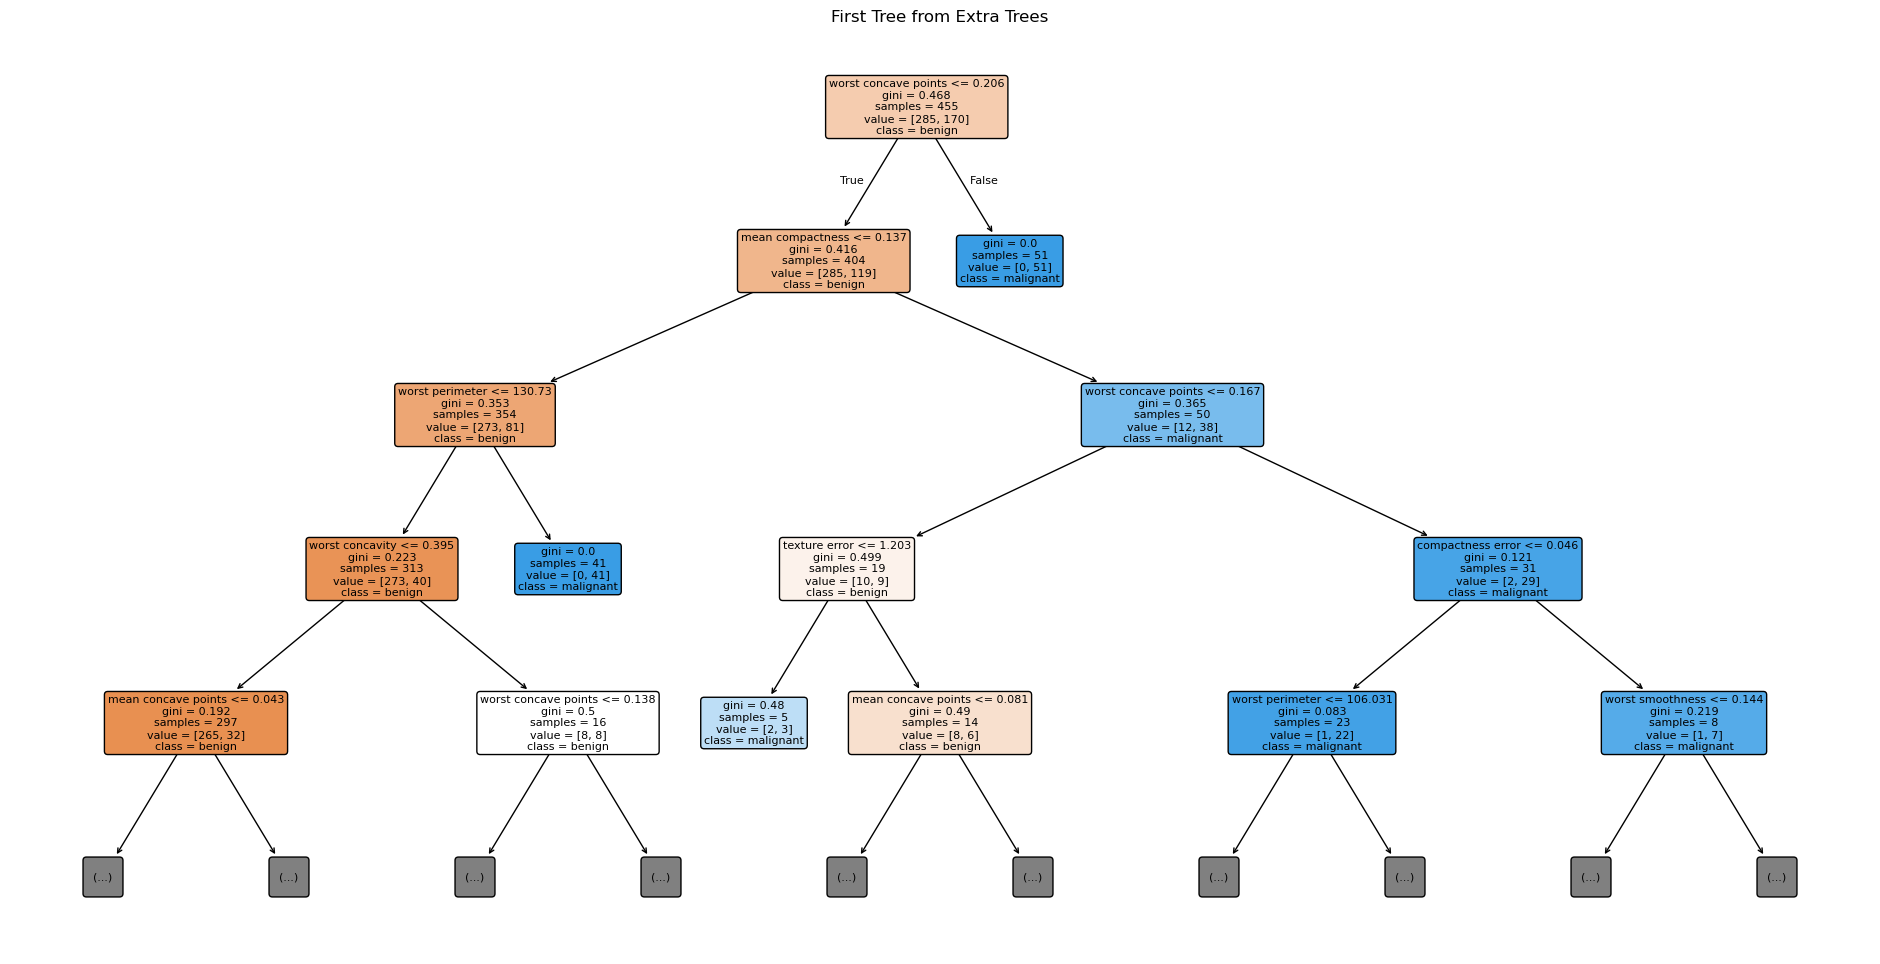

In [16]:
# Function to extract one tree from a tree-based model
def get_tree_to_plot(model):
    
    if isinstance(model, DecisionTreeClassifier):
        return model, "Decision Tree"
    
    elif isinstance(model, (RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier)):
        return model.estimators_[0], f"First Tree from {best_model_name}"
    
    elif isinstance(model, AdaBoostClassifier):
        return model.estimators_[0], f"First Weak Tree from {best_model_name}"
    
    elif isinstance(model, GradientBoostingClassifier):
        return model.estimators_[0, 0], f"First Tree from {best_model_name}"
    
    else:
        return None, None

tree_to_plot, tree_title = get_tree_to_plot(best_model)


if tree_to_plot is not None:
    
    plt.figure(figsize=(24, 12))
    
    plot_tree(tree_to_plot, feature_names=X_train.columns, class_names=["benign", "malignant"],
        filled=True, rounded=True, max_depth=4, fontsize=8 )
    
    plt.title(tree_title)

    # Save figure
    plt.savefig("tree_plot.png", dpi=300, bbox_inches="tight")
    # plt.savefig(output_dir / "tree_plot.pdf", bbox_inches="tight")

    plt.show()

else:
    print(f"{best_model_name} is not directly tree-based, so there is no single tree to plot.")

In [17]:
best_f1_model_name = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

print("Best Model Based on F1 Score")
print("----------------------------")
print(best_f1_model_name)

Best Model Based on F1 Score
----------------------------
Voting Classifier


### Classification reports

In [18]:
for model_name in models.keys():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions[model_name],
        target_names=["benign", "malignant"]
    ))

Decision Tree
              precision    recall  f1-score   support

      benign       0.88      1.00      0.94        72
   malignant       1.00      0.76      0.86        42

    accuracy                           0.91       114
   macro avg       0.94      0.88      0.90       114
weighted avg       0.92      0.91      0.91       114

Bagging
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Random Forest
              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96     

### Cross validation

In [19]:
cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42 )

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results_list = []

for model_name, model in models.items():

    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1 )

    cv_results_list.append({
        "Model": model_name,
        "CV Accuracy Mean": cv_results["test_accuracy"].mean(),
        "CV Accuracy Std": cv_results["test_accuracy"].std(),
        "CV Precision Mean": cv_results["test_precision"].mean(),
        "CV Recall Mean": cv_results["test_recall"].mean(),
        "CV F1 Mean": cv_results["test_f1"].mean(),
        "CV ROC AUC Mean": cv_results["test_roc_auc"].mean(),
        "CV ROC AUC Std": cv_results["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results_list)

cv_results_df.sort_values(
    by="CV ROC AUC Mean", ascending=False )

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC AUC Mean,CV ROC AUC Std
9,Stacking Classifier,0.975824,0.010767,0.983007,0.952941,0.966858,0.995459,0.004359
8,Voting Classifier,0.973626,0.008791,0.983007,0.947059,0.963782,0.995150,0.004482
7,XGBoost,0.967033,0.012038,0.959128,0.952941,0.955738,0.993911,0.004334
6,Hist Gradient Boosting,0.962637,0.020382,0.964342,0.935294,0.948470,0.993602,0.003897
3,Extra Trees,0.962637,0.024670,0.969484,0.929412,0.948792,0.991434,0.005696
5,Gradient Boosting,0.969231,0.014579,0.970177,0.947059,0.958097,0.990712,0.006336
4,AdaBoost,0.960440,0.022628,0.969804,0.923529,0.945505,0.988854,0.007623
2,Random Forest,0.953846,0.017582,0.941856,0.935294,0.937885,0.987100,0.007646
1,Bagging,0.958242,0.024474,0.958801,0.929412,0.943031,0.986429,0.010462
0,Decision Tree,0.923077,0.026005,0.910205,0.882353,0.894903,0.955934,0.020963


### Final comparison table

In [20]:
final_comparison = results_df.merge(
    cv_results_df,
    on="Model",
    how="left"
)

final_comparison = final_comparison.sort_values(
    by="ROC AUC",
    ascending=False
)

final_comparison

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,Average Precision,Log Loss,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC AUC Mean,CV ROC AUC Std
3,Extra Trees,0.956140,1.0,0.880952,1.0,0.936709,0.998677,0.997770,0.111662,0.962637,0.024670,0.969484,0.929412,0.948792,0.991434,0.005696
8,Voting Classifier,0.991228,1.0,0.976190,1.0,0.987952,0.996362,0.995058,0.085847,0.973626,0.008791,0.983007,0.947059,0.963782,0.995150,0.004482
9,Stacking Classifier,0.991228,1.0,0.976190,1.0,0.987952,0.996032,0.994709,0.071756,0.975824,0.010767,0.983007,0.952941,0.966858,0.995459,0.004359
4,AdaBoost,0.964912,1.0,0.904762,1.0,0.950000,0.994709,0.993432,0.286192,0.960440,0.022628,0.969804,0.923529,0.945505,0.988854,0.007623
5,Gradient Boosting,0.964912,1.0,0.904762,1.0,0.950000,0.994378,0.991542,0.134009,0.969231,0.014579,0.970177,0.947059,0.958097,0.990712,0.006336
2,Random Forest,0.964912,1.0,0.904762,1.0,0.950000,0.994378,0.991584,0.118390,0.953846,0.017582,0.941856,0.935294,0.937885,0.987100,0.007646
6,Hist Gradient Boosting,0.973684,1.0,0.928571,1.0,0.962963,0.994378,0.992865,0.108341,0.962637,0.020382,0.964342,0.935294,0.948470,0.993602,0.003897
7,XGBoost,0.973684,1.0,0.928571,1.0,0.962963,0.994378,0.993140,0.084221,0.967033,0.012038,0.959128,0.952941,0.955738,0.993911,0.004334
1,Bagging,0.973684,1.0,0.928571,1.0,0.962963,0.990410,0.986422,0.119150,0.958242,0.024474,0.958801,0.929412,0.943031,0.986429,0.010462
0,Decision Tree,0.912281,1.0,0.761905,1.0,0.864865,0.968750,0.953339,0.476887,0.923077,0.026005,0.910205,0.882353,0.894903,0.955934,0.020963


### Conclusion

The ensemble models perform very well overall. Extra Trees has the highest ROC AUC, meaning it separates malignant and benign tumors extremely well across thresholds. However, Voting Classifier and Stacking Classifier have the best overall balance, with the highest accuracy, F1 score, strong recall, perfect precision, and strong cross-validation performance.

The single Decision Tree performs the worst, which is expected because a single tree is more likely to overfit or miss important patterns. Ensemble methods improve performance by combining multiple learners.

Overall, the Voting Classifier or Stacking Classifier would be the best final choice if the goal is strong predictive performance. If interpretability is more important, Extra Trees or Random Forest feature importance can help explain which tumor features contribute most to prediction.

### Plot ROC curves

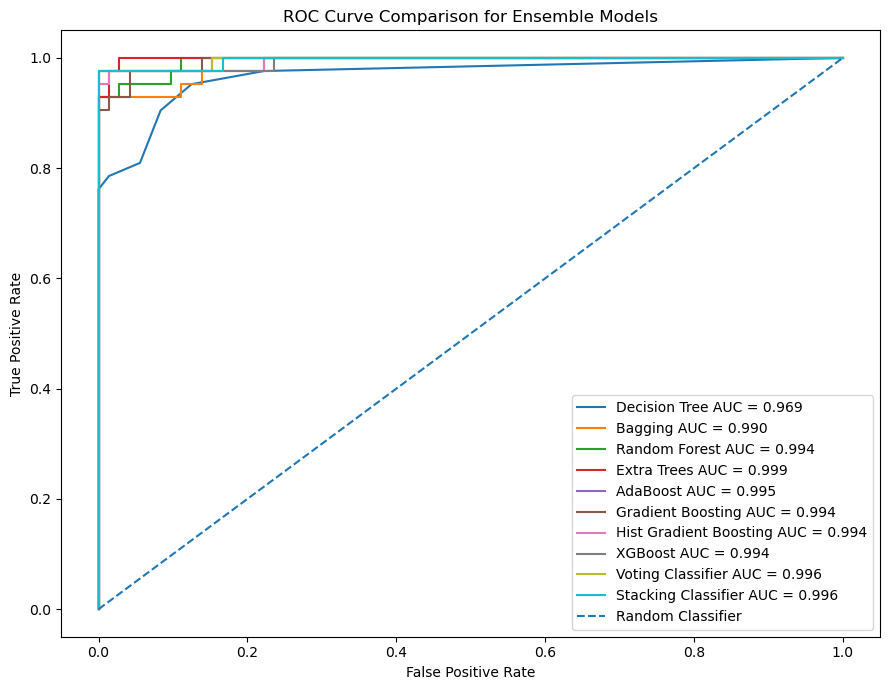

In [21]:
plt.figure(figsize=(9, 7))

for model_name in models.keys():
    fpr, tpr, thresholds = roc_curve(y_test, probabilities[model_name])
    auc_score = roc_auc_score(y_test, probabilities[model_name])

    plt.plot(
        fpr, tpr,
        label=f"{model_name} AUC = {auc_score:.3f}" )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Ensemble Models")
plt.legend()
plt.tight_layout()
plt.show()

### Plot precision recall curves

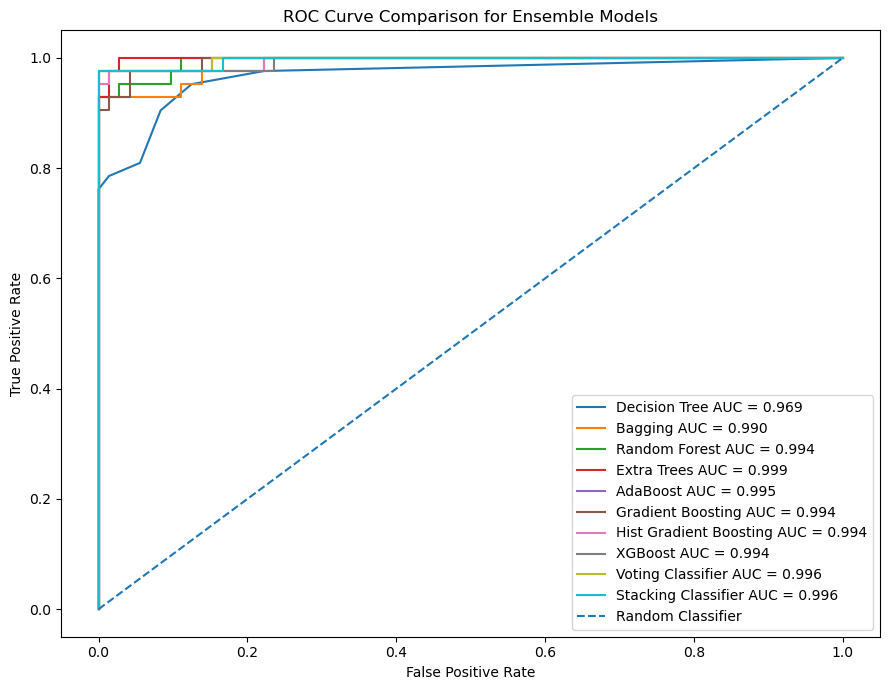

In [22]:
plt.figure(figsize=(9, 7))

for model_name in models.keys():
    fpr, tpr, thresholds = roc_curve(y_test, probabilities[model_name])
    auc_score = roc_auc_score(y_test, probabilities[model_name])

    plt.plot(
        fpr, tpr,
        label=f"{model_name} AUC = {auc_score:.3f}" )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Ensemble Models")
plt.legend()
plt.tight_layout()
plt.show()

### Confusion matrix for the best model (Extra Trees)

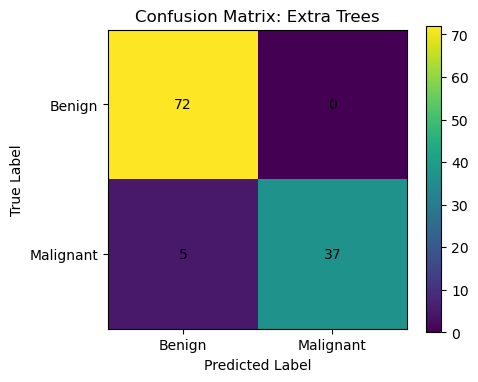

In [23]:
best_model_name = final_comparison.iloc[0]["Model"]
best_predictions = predictions[best_model_name]

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

labels = ["Benign", "Malignant"]

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### Feature importance from Extra Trees

In [24]:
extra_trees_model = models["Extra Trees"]

extra_trees_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": extra_trees_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

extra_trees_importance.head(10)

,Feature,Importance
27,worst concave points,0.104778
20,worst radius,0.101847
22,worst perimeter,0.096546
7,mean concave points,0.088482
23,worst area,0.075736
0,mean radius,0.069910
6,mean concavity,0.062750
2,mean perimeter,0.053630
3,mean area,0.052933
26,worst concavity,0.042224


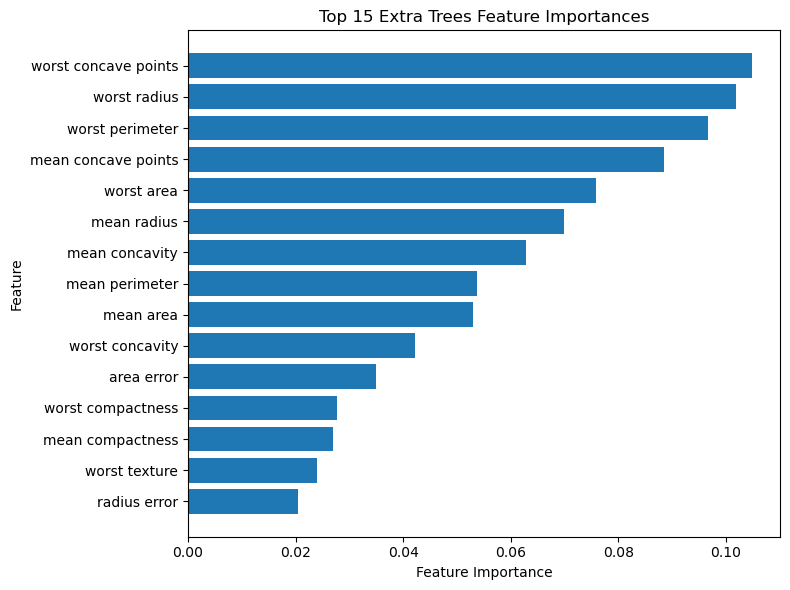

In [25]:
plt.figure(figsize=(8, 6))

plt.barh(
    extra_trees_importance.head(15)["Feature"],
    extra_trees_importance.head(15)["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Extra Trees Feature Importances")
plt.tight_layout()
plt.show()

### Make a single prediction

In [26]:
new_observation = X_test.iloc[[0]]

predicted_class = best_model.predict(new_observation)[0]
predicted_probability = best_model.predict_proba(new_observation)[0, 1]

class_labels = {
    0: "benign",
    1: "malignant"
}

print("Single Prediction")
print("-----------------")
print(f"Best model: {best_model_name}")
print(f"Predicted class: {predicted_class}")
print(f"Predicted diagnosis: {class_labels[predicted_class]}")
print(f"Probability of malignant tumor: {predicted_probability:.3f}")

Single Prediction
-----------------
Best model: Extra Trees
Predicted class: 0
Predicted diagnosis: benign
Probability of malignant tumor: 0.010


### Optional Save tables and figures

In [27]:
figures_dir = Path("reports/figures/ensemble_learning")
tables_dir = Path("reports/tables")

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

final_comparison.to_csv(
    tables_dir / "ensemble_model_comparison.csv",
    index=False
)

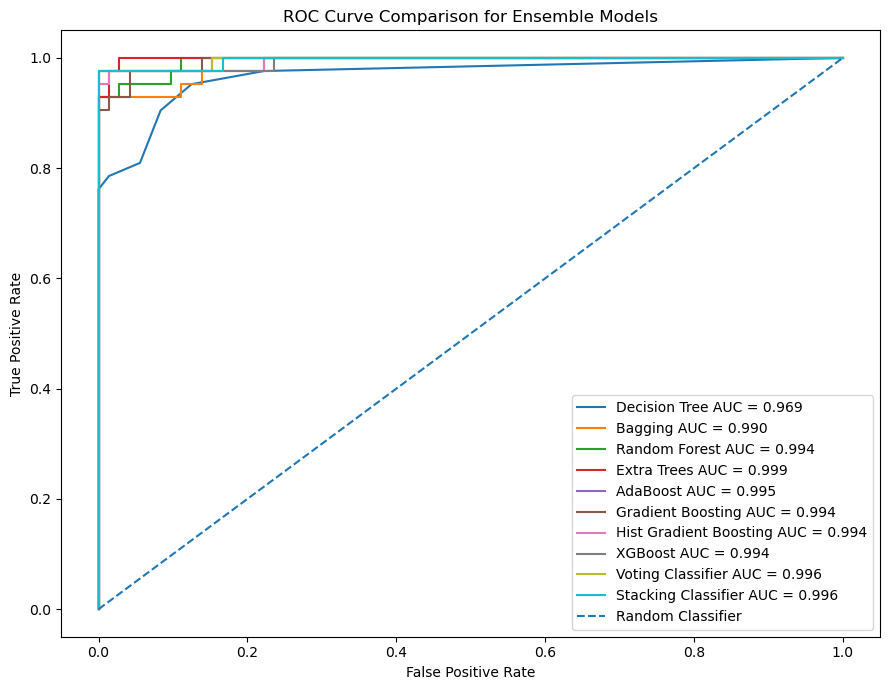

In [28]:
plt.figure(figsize=(9, 7))

for model_name in models.keys():
    fpr, tpr, thresholds = roc_curve(y_test, probabilities[model_name])
    auc_score = roc_auc_score(y_test, probabilities[model_name])

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC = {auc_score:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Ensemble Models")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "ensemble_roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Feature importance from Random Forest

In [30]:
rf_model = models["Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
22,worst perimeter,0.149525
23,worst area,0.149228
27,worst concave points,0.116447
7,mean concave points,0.092975
20,worst radius,0.087495
0,mean radius,0.062190
2,mean perimeter,0.053422
3,mean area,0.043226
6,mean concavity,0.040682
26,worst concavity,0.032020


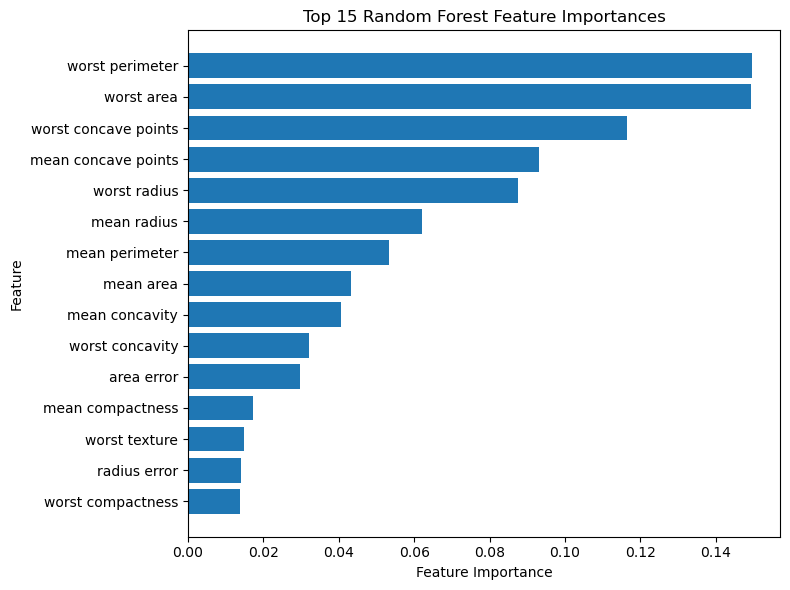

In [32]:
plt.figure(figsize=(8, 6))

plt.barh(
    rf_importance.head(15)["Feature"],
    rf_importance.head(15)["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(figures_dir / "random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()